In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
product_analysis = pd.read_excel("../data/processed/product_analysis.xlsx")

batch_analysis = pd.read_excel("../data/processed/batch_analysis.xlsx")

daily_sales = pd.read_excel("../data/processed/daily_sales.xlsx")

size_analysis = pd.read_excel("../data/processed/size_analysis.xlsx")

summary = pd.read_excel("../data/processed/summary.xlsx")

refund_analysis = pd.read_excel("../data/processed/refund_analysis.xlsx")

In [14]:
product_analysis.head()

,商品名称,GMV,销量,订单数
0,徽章,8079.4,274,269
1,棒球服,7439.0,43,43


In [15]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

## 商品GMV对比

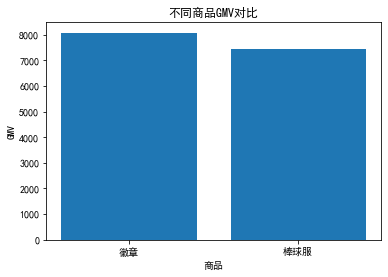

In [16]:
plt.figure(figsize=(6,4))

plt.bar(
    product_analysis["商品名称"],
    product_analysis["GMV"]
)

plt.xlabel("商品")
plt.ylabel("GMV")
plt.title("不同商品GMV对比")
plt.savefig("../images/product_gmv.png",bbox_inches="tight")

plt.show()

## 商品销量对比

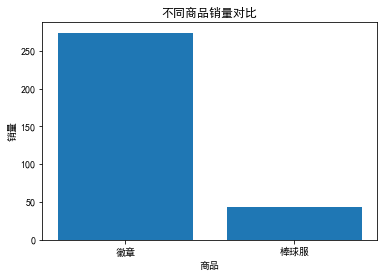

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    product_analysis["商品名称"],
    product_analysis["销量"]
)

plt.xlabel("商品")
plt.ylabel("销量")
plt.title("不同商品销量对比")
plt.savefig("../images/product_sales.png",bbox_inches="tight")

plt.show()

徽章是主要销量来源，而棒球服依靠更高单价贡献更多收入

## 销售批次GMV对比

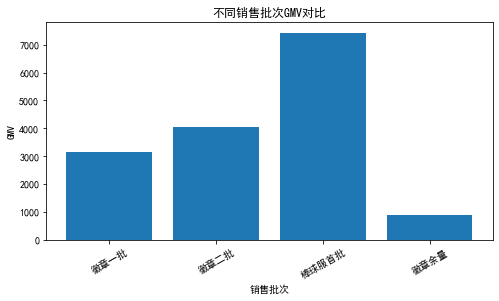

In [18]:
plt.figure(figsize=(8,4))

plt.bar(
    batch_analysis["销售批次"],
    batch_analysis["GMV"]
)

plt.xlabel("销售批次")
plt.ylabel("GMV")
plt.title("不同销售批次GMV对比")

plt.xticks(rotation=30)
plt.savefig("../images/batch_gmv.png",bbox_inches="tight")

plt.show()

棒球服虽然销量较低，但由于单价较高，对整体收入贡献最大；徽章二批相比首批销售表现有所提升。

## 每日销售额趋势

In [19]:
daily_sales["日期"] = pd.to_datetime(
    daily_sales["日期"]
)

daily_sales = daily_sales.sort_values(
    "日期"
)

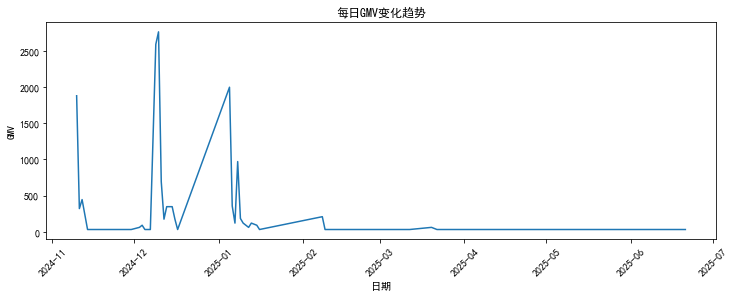

In [20]:
plt.figure(figsize=(12,4))

plt.plot(
    daily_sales["日期"],
    daily_sales["GMV"]
)

plt.xlabel("日期")
plt.ylabel("GMV")
plt.title("每日GMV变化趋势")

plt.xticks(rotation=45)
plt.savefig("../images/daily_gmv_trend.png",bbox_inches="tight")

plt.show()

月度销售额呈现阶段性变化，销售高峰集中在某些月份，说明销售活动或新品发售时间对GMV有明显影响。

## 棒球服尺码销量分析

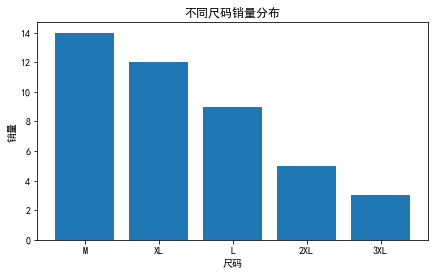

In [21]:
plt.figure(figsize=(7,4))

plt.bar(
    size_analysis["商品型号"],
    size_analysis["销量"]
)

plt.xlabel("尺码")
plt.ylabel("销量")
plt.title("不同尺码销量分布")
plt.savefig("../images/size_analysis.png",bbox_inches="tight")

plt.show()

棒球服销售主要集中在M和XL尺码，后续备货时可以根据历史销量调整不同尺码库存比例。

## 售后退款分析

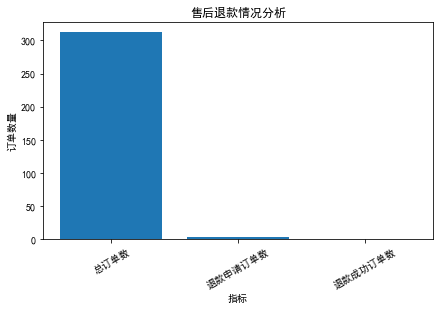

In [22]:
plt.figure(figsize=(7,4))

refund_plot = refund_analysis[
    refund_analysis["指标"].isin(
        ["总订单数", "退款申请订单数", "退款成功订单数"]
    )
]

plt.bar(
    refund_plot["指标"],
    refund_plot["数值"]
)

plt.xlabel("指标")
plt.ylabel("订单数量")
plt.title("售后退款情况分析")

plt.xticks(rotation=30)
plt.savefig("../images/refund_analysis.png",bbox_inches="tight")

plt.show()

### 分析结论

退款申请订单数较少，仅3笔，其中2笔取消退款，成功退款1笔，实际退款率为0.32%，说明整体商品销售后的售后情况较稳定。